In [2]:
# --------------------------------------------
#  1. Lectura del archivo NetCDF con xarray y dask 
# --------------------------------------------
import os
import xarray as xr

nc_file = r"E:\ProgramacionSIG\data_heavy\era5_2m_temperature_2025_04_colombia.nc"
if os.path.exists(nc_file):
    ds = xr.open_dataset(nc_file, chunks="auto")  # lectura lazy con dask
    print("Estructura del dataset:")
    print(ds)
    print(f"\nDimensiones: {dict(ds.sizes)}")
    print(f"Variables: {list(ds.data_vars)}")
else:
    print(f"Error: no existe {nc_file}")

Estructura del dataset:
<xarray.Dataset> Size: 89kB
Dimensions:     (valid_time: 720, latitude: 5, longitude: 5)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2025-04-01 ... 2025-04-30T23:...
    expver      (valid_time) <U4 12kB dask.array<chunksize=(720,), meta=np.ndarray>
  * latitude    (latitude) float64 40B 4.0 3.75 3.5 3.25 3.0
  * longitude   (longitude) float64 40B -75.0 -74.75 -74.5 -74.25 -74.0
    number      int64 8B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 72kB dask.array<chunksize=(720, 5, 5), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-25T20:32 GRIB to CDM+CF via cfgrib-0.9.1...

Dimensiones: {'valid_time': 720, 'latitude': 5, 'longitude': 5

In [ ]:
# --------------------------------------------
#  2. Lectura del archivo NetCDF con xarray y dask 
# --------------------------------------------
import rioxarray

ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=False)
if ds.rio.crs is None:
    ds = ds.rio.write_crs("EPSG:4326", inplace=False)

print(f"CRS actual: {ds.rio.crs}")

CRS actual: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


Algebra de Mapas 

In [ ]:
# --------------------------------------------
#  3. Conversión de kelvin a Celsius y agregación temporal
# --------------------------------------------
temp_var = "t2m" if "t2m" in ds.data_vars else ("t" if "t" in ds.data_vars else "tp")
time_dim = "valid_time" if "valid_time" in ds.dims else "time"
is_temp = temp_var in ["t2m", "t"]

da_conv = ds[temp_var] - 273.15 if is_temp else ds[temp_var] * 1000
da_conv.attrs["units"] = "°C" if is_temp else "mm"
agg = "mean" if is_temp else "sum"

t_mean = da_conv.mean(dim=time_dim)
print(f"Variable: {temp_var} | Unidad: {da_conv.attrs['units']} | Agregacion diaria: {agg}")
t_mean

Variable: t2m | Unidad: °C | Agregacion diaria: mean


<xarray.DataArray 't2m' (latitude: 5, longitude: 5)> Size: 100B
dask.array<mean_agg-aggregate, shape=(5, 5), dtype=float32, chunksize=(5, 5), chunktype=numpy.ndarray>
Coordinates:
  * latitude     (latitude) float64 40B 4.0 3.75 3.5 3.25 3.0
  * longitude    (longitude) float64 40B -75.0 -74.75 -74.5 -74.25 -74.0
    number       int64 8B ...
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      25
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    °C
    standard_name:                            unknown
    GRIB_surface:                             0.0

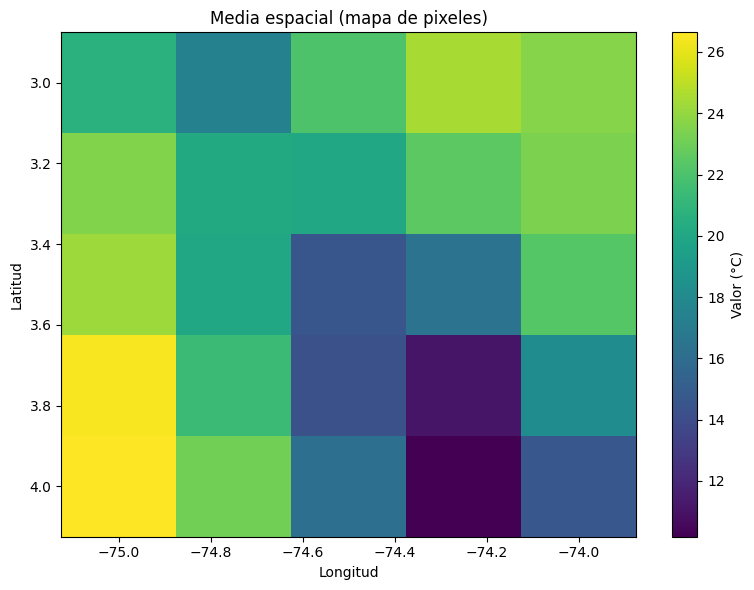

In [6]:
# --------------------------------------------
#  4. Graficar media como mapa de pixeles
# --------------------------------------------
import matplotlib.pyplot as plt

da_plot = t_mean.squeeze()
dims_to_reduce = [d for d in da_plot.dims if d not in ("latitude", "longitude")]
if dims_to_reduce:
    da_plot = da_plot.mean(dim=dims_to_reduce)

if da_plot.ndim == 2:
    plt.figure(figsize=(8, 6))
    da_plot.plot.imshow(
        cmap="viridis",
        interpolation="nearest",
        yincrease=False,
        cbar_kwargs={"label": f"Valor ({da_conv.attrs.get('units', '')})"}
    )
    plt.title("Media espacial (mapa de pixeles)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.tight_layout()
    plt.show()

In [8]:
# --------------------------------------------
#  5. Unidades actuales en celsius
# --------------------------------------------
t_celsius = da_conv
print(f"Unidad actual: {t_celsius.attrs.get('units')}")

Unidad actual: °C


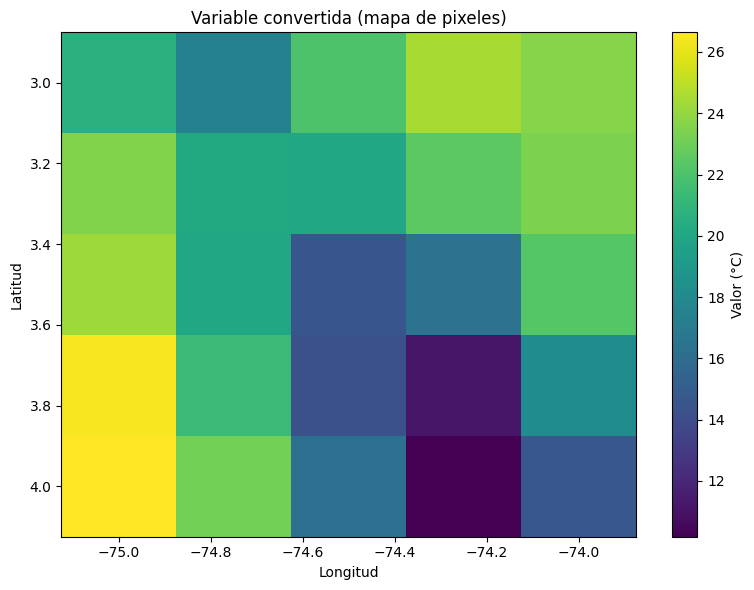

In [9]:
# --------------------------------------------
#  6. Graficar variable convertida como mapa de pixeles
# --------------------------------------------
import matplotlib.pyplot as plt

da_plot = t_celsius.squeeze()
dims_to_reduce = [d for d in da_plot.dims if d not in ("latitude", "longitude")]
if dims_to_reduce:
    da_plot = da_plot.mean(dim=dims_to_reduce)

if da_plot.ndim == 2:
    plt.figure(figsize=(8, 6))
    da_plot.plot.imshow(
        cmap="viridis",
        interpolation="nearest",
        yincrease=False,
        cbar_kwargs={"label": f"Valor ({t_celsius.attrs.get('units', '')})"}
    )
    plt.title("Variable convertida (mapa de pixeles)")
    plt.xlabel("Longitud")
    plt.ylabel("Latitud")
    plt.tight_layout()
    plt.show()

In [11]:
# --------------------------------------------
#  6. Crear un índice de tiempo con pandas para verificar las fechas
# --------------------------------------------
import pandas as pd
time_index = pd.to_datetime(ds[time_dim].values)
print(time_index[:5], "...", time_index[-1])

DatetimeIndex(['2025-04-01 00:00:00', '2025-04-01 01:00:00',
               '2025-04-01 02:00:00', '2025-04-01 03:00:00',
               '2025-04-01 04:00:00'],
              dtype='datetime64[ns]', freq=None) ... 2025-04-30 23:00:00


In [12]:
# --------------------------------------------
#  7. Calculamos la diferencia entre los dos primeros registros de tiempo
# --------------------------------------------
delta_time = time_index[1] - time_index[0]
print(f"Resolución temporal: {delta_time}")

Resolución temporal: 0 days 01:00:00


In [13]:
# -------------------------------------------------------------------------
# 8. Remuestreo temporal con xarray (Resampling)
# -------------------------------------------------------------------------
t_diaria = t_celsius.resample({time_dim: "1D"}).mean()
print("\n--- Temperatura diaria promedio ---")
print(t_diaria)
print("\n--- Tiempo original ---")
print(t_celsius[time_dim])


--- Temperatura diaria promedio ---
<xarray.DataArray 't2m' (valid_time: 30, latitude: 5, longitude: 5)> Size: 3kB
dask.array<stack, shape=(30, 5, 5), dtype=float32, chunksize=(1, 5, 5), chunktype=numpy.ndarray>
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 240B 2025-04-01 ... 2025-04-30
  * latitude     (latitude) float64 40B 4.0 3.75 3.5 3.25 3.0
  * longitude    (longitude) float64 40B -75.0 -74.75 -74.5 -74.25 -74.0
    number       int64 8B ...
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      25
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                     

In [14]:
# -------------------------------------------------------------------------
# 9. Calculamos el valor máximo mensual para cada píxel
# -------------------------------------------------------------------------
t_mensual_max = t_diaria.resample({time_dim: "1M"}).max()
print("\n--- Temperatura máxima mensual ---")
print(t_mensual_max)


--- Temperatura máxima mensual ---
<xarray.DataArray 't2m' (valid_time: 1, latitude: 5, longitude: 5)> Size: 100B
dask.array<stack, shape=(1, 5, 5), dtype=float32, chunksize=(1, 5, 5), chunktype=numpy.ndarray>
Coordinates:
  * valid_time   (valid_time) datetime64[ns] 8B 2025-04-30
  * latitude     (latitude) float64 40B 4.0 3.75 3.5 3.25 3.0
  * longitude    (longitude) float64 40B -75.0 -74.75 -74.5 -74.25 -74.0
    number       int64 8B ...
    spatial_ref  int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      25
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre 

e:\ProgramacionSIG\Talleres\.venv\Lib\site-packages\xarray\groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [15]:
# -------------------------------------------------------------------------
# 10. Calculamos la fecha del valor máximo mensual para cada píxel
# -------------------------------------------------------------------------
def fecha_max_mensual(x):
    x = x.compute()
    return x.idxmax(dim=time_dim)

t_mensual_fecha_max = t_diaria.resample({time_dim: "1MS"}).map(fecha_max_mensual)
print("\n--- Fecha del maximo mensual ---")
print(t_mensual_fecha_max)


--- Fecha del maximo mensual ---
<xarray.DataArray 'valid_time' (valid_time: 1, latitude: 5, longitude: 5)> Size: 200B
array([[['2025-04-15T00:00:00.000000000',
         '2025-04-15T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000'],
        ['2025-04-16T00:00:00.000000000',
         '2025-04-16T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000',
         '2025-04-27T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000'],
        ['2025-04-15T00:00:00.000000000',
         '2025-04-15T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000',
         '2025-04-27T00:00:00.000000000',
         '2025-04-14T00:00:00.000000000'],
        ['2025-04-15T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000',
         '2025-04-27T00:00:00.000000000',
         '2025-04-13T00:00:00.000000000',
         '2025-04-15T00:00:00.000000000'],
        ['2025-04-15T00:00:00.000000

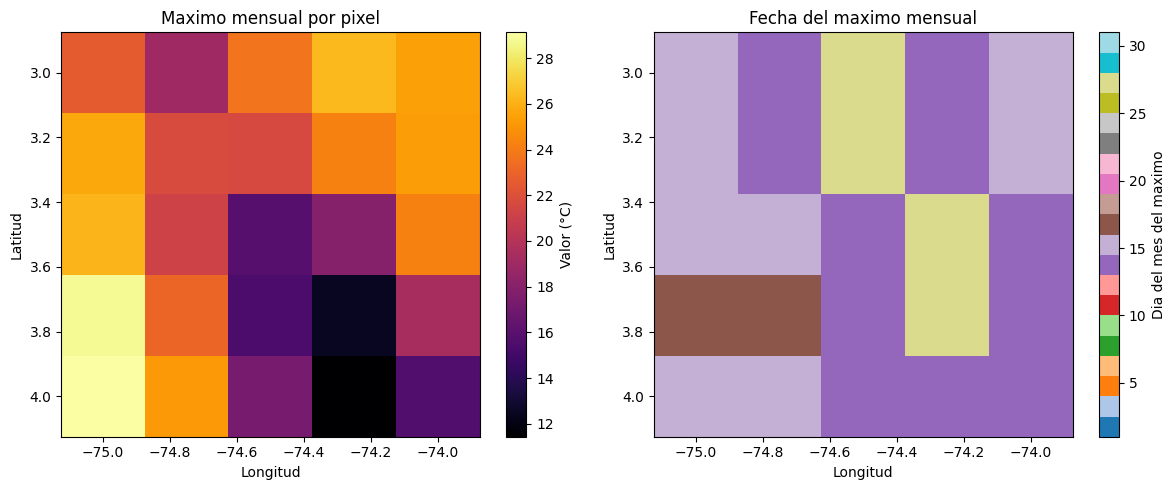

In [16]:
# -------------------------------------------------------------------------
# 11. Visualizamos la fecha del valor máximo mensual para cada píxel
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt

max_plot = t_mensual_max.squeeze()
fecha_plot = t_mensual_fecha_max.squeeze()
dia_max = fecha_plot.dt.day

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
max_plot.plot.imshow(
    ax=ax[0],
    cmap="inferno",
    yincrease=False,
    cbar_kwargs={"label": f"Valor ({t_celsius.attrs.get('units', '')})"}
 )
ax[0].set_title("Maximo mensual por pixel")
ax[0].set_xlabel("Longitud")
ax[0].set_ylabel("Latitud")

dia_max.plot.imshow(
    ax=ax[1],
    cmap="tab20",
    vmin=1, vmax=31,
    yincrease=False,
    cbar_kwargs={"label": "Dia del mes del maximo"}
 )
ax[1].set_title("Fecha del maximo mensual")
ax[1].set_xlabel("Longitud")
ax[1].set_ylabel("Latitud")

plt.tight_layout()
plt.show()

In [17]:
# -------------------------------------------------------------------------
# 12. Exportamos el resultado a un nuevo archivo NetCDF
# -------------------------------------------------------------------------
t_mensual_max.to_netcdf("mi_zona_procesada.nc")
print("Archivo 'mi_zona_procesada.nc' exportado exitosamente.")

Archivo 'mi_zona_procesada.nc' exportado exitosamente.
